CSCI218 GroupProject Machine Learning (Rice Data Sets) (Logical Regression)

**Environment Setup and Data Extraction**

In [ ]:
# Libraries for data handling
import pandas as pd
from scipy.io import arff
import zipfile
import os

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Unzip the dataset
# Note: Ensure the .zip file is uploaded to your Colab session or Drive
zip_path = '/content/drive/MyDrive/rice+cammeo+and+osmancik.zip'
extract_path = '/content/rice_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully:", os.listdir(extract_path))

Files extracted successfully: ['Rice_Cammeo_Osmancik.arff', 'Citation_Request.txt']


**Data Loading and Initial Cleaning**

In [ ]:
# Load the .arff file
data, meta = arff.loadarff('/content/rice_data/Rice_Cammeo_Osmancik.arff')
df = pd.DataFrame(data)

# Convert byte strings (e.g., b'Cammeo') to standard strings
df['Class'] = df['Class'].str.decode('utf-8')

# Display the first few rows and data info
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   float64
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   float64
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(7), object(1)
memory usage: 238.3+ KB
None


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


**Exploratory Data Analysis**

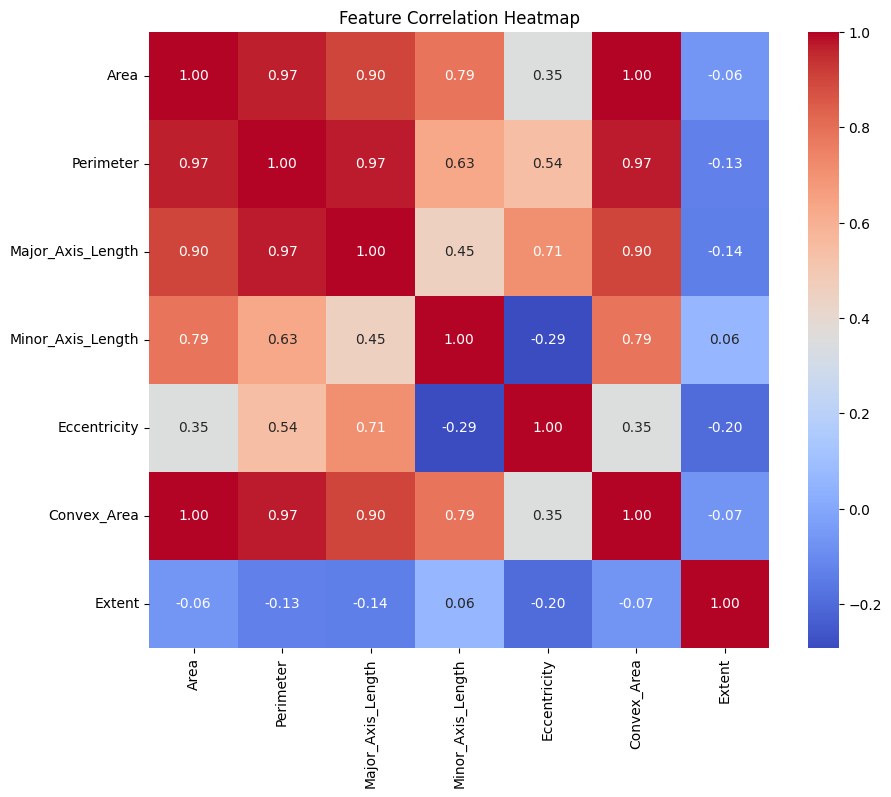

/tmp/ipython-input-3885049387.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=df, palette="Set2")
/tmp/ipython-input-3885049387.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=df, palette="Set2")
/tmp/ipython-input-3885049387.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=df, palette="Set2")
/tmp/ipython-input-3885049387.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to 

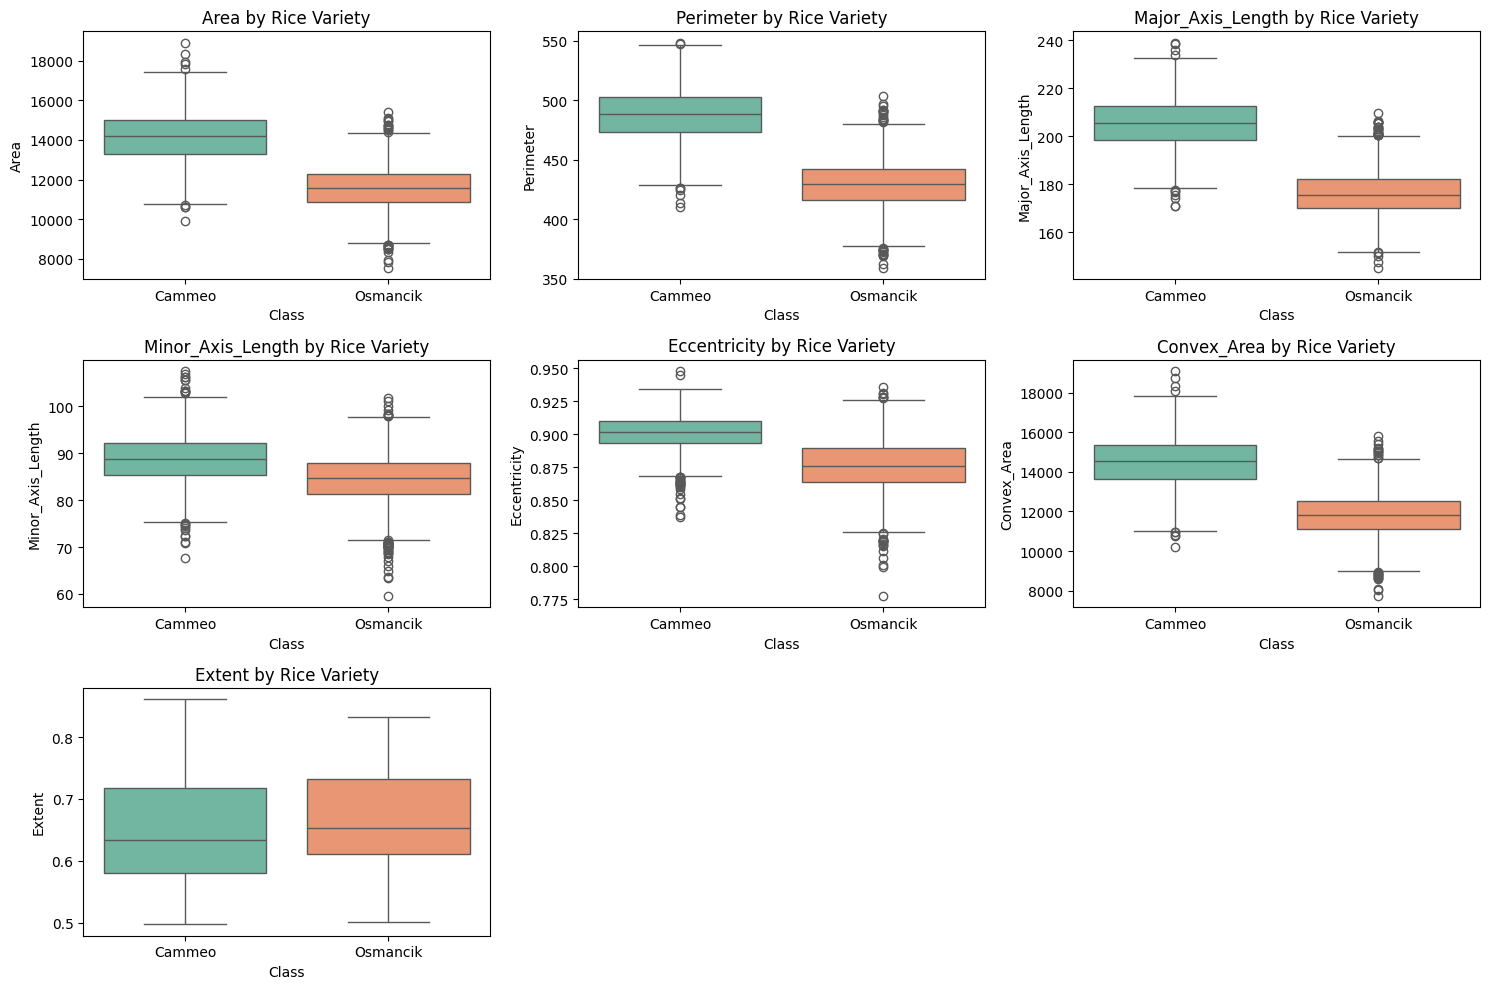

In [ ]:
# 1. Correlation Heatmap to see feature relationships
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('Class', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 2. Boxplots to compare feature distributions by class
plt.figure(figsize=(15, 10))
features = df.drop('Class', axis=1).columns
for i, col in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='Class', y=col, data=df, palette="Set2")
    plt.title(f'{col} by Rice Variety')
plt.tight_layout()
plt.show()

**Data Preprocessing**

In [ ]:
# Split Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling: Standardize features to have mean=0 and variance=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully scaled and split.")

Data successfully scaled and split.


**Model Training and Cross-Validation**

In [ ]:
# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000)

# Perform 5-Fold Cross-Validation on training data
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)

# Fit the model on the full training set
log_reg.fit(X_train_scaled, y_train)

print(f"Cross-Validation Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.4f}")

Cross-Validation Mean Accuracy: 0.9268
Standard Deviation of CV Scores: 0.0089


**Advanced Model Evaluation**


Classification Report:
               precision    recall  f1-score   support

      Cammeo       0.92      0.93      0.92       350
    Osmancik       0.94      0.93      0.93       412

    accuracy                           0.93       762
   macro avg       0.93      0.93      0.93       762
weighted avg       0.93      0.93      0.93       762



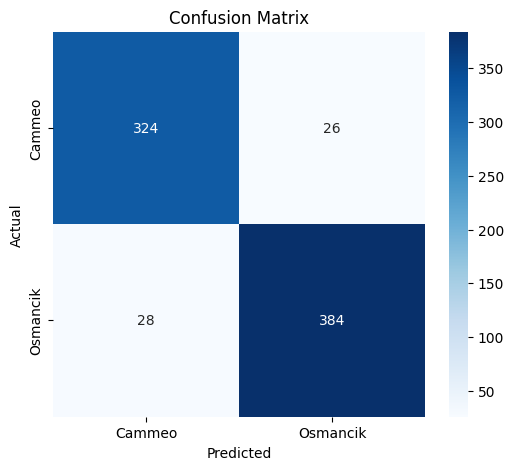

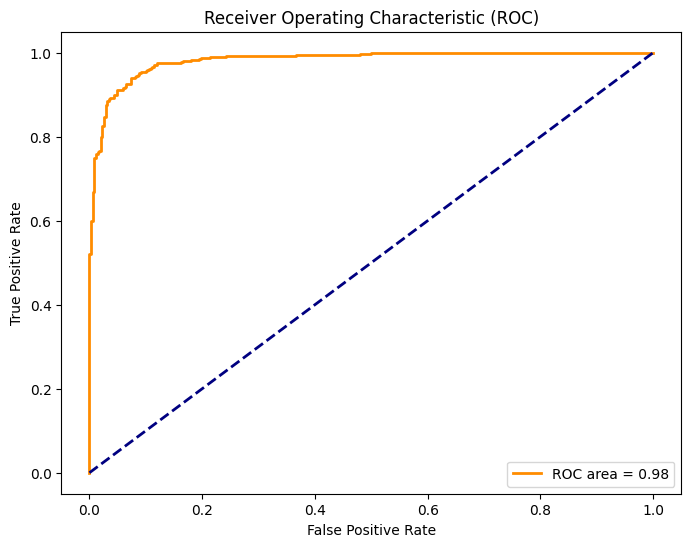

In [ ]:
# Generate Predictions
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1] # Probability for ROC curve

# 1. Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=log_reg.classes_, yticklabels=log_reg.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 3. ROC Curve
# Convert labels to 0 and 1 for ROC calculation
y_test_binary = y_test.map({'Cammeo': 0, 'Osmancik': 1})
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC area = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

**Feature Importance and Insights**

/tmp/ipython-input-2352572692.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance, palette="viridis")


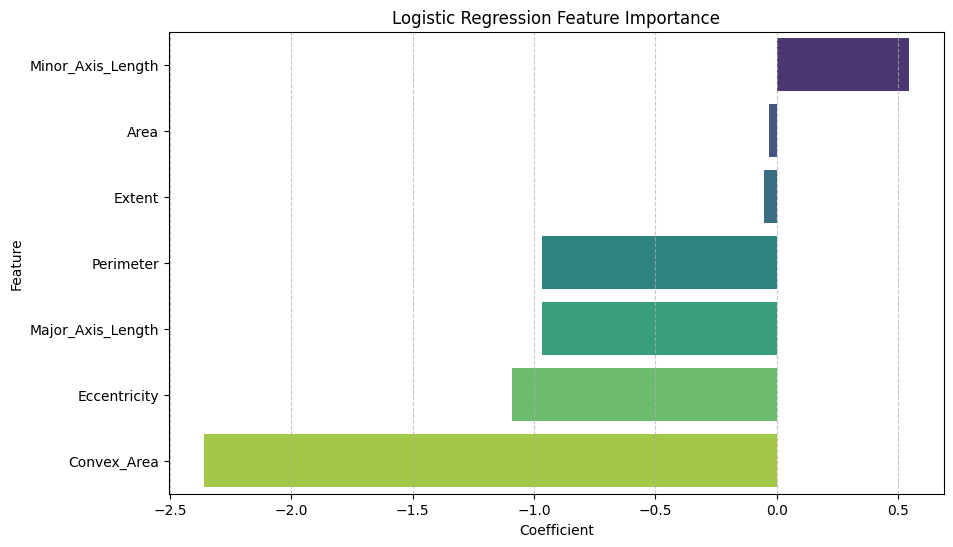

Interpretation Note: Features with high absolute coefficients are the strongest predictors.


In [ ]:
# Extract and visualize coefficients
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
importance = importance.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=importance, palette="viridis")
plt.title('Logistic Regression Feature Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Interpretation Note: Features with high absolute coefficients are the strongest predictors.")